In [46]:
import reda

In [57]:
configs = reda.ConfigManager(72)

In [58]:
configs.clear_configs()
configs.gen_dipole_dipole(skipc=1, stepc=1, stepv=2)
print(configs.configs)

[[ 1  3  4  6]
 [ 1  3  6  8]
 [ 1  3  8 10]
 ...
 [65 67 70 72]
 [66 68 69 71]
 [67 69 70 72]]


In [59]:
import pandas as pd

In [60]:
df = pd.DataFrame(configs.configs, columns=['a', 'b', 'm', 'n'])

In [61]:
g = df.groupby(['a', 'b'])

In [62]:
"""
N  minj time_est
22  250  38s
22  500  57s
22 1000 1:36

43  250 1:47
43  500 2:57
43 1000 5:17

72 Elecs
72  67 250 2:47
72 67 500 4:36
72 67 1000 8:14
"""
N = len(list(g.groups.keys()))
stacks = 1
# [s]
t_inj = 0.250

time_per_injection = t_inj * 4 * stacks
time_total_est = N * time_per_injection

print('Nr of injections:', N)
print('Estimated total measurement time:', time_total_est, 's')

Nr of injections: 67
Estimated total measurement time: 67.0 s


In [ ]:
df['r'] = 1

In [69]:
Nel = 72
dfr = df.copy()
dfr['a'] = (Nel + 1) - df['a']
dfr['b'] = (Nel + 1) - df['b']
dfr['m'] = (Nel + 1) - df['m']
dfr['n'] = (Nel + 1) - df['n']

print(dfr)

      a   b   m   n  r
0    72  70  69  67  1
1    72  70  67  65  1
2    72  70  65  63  1
3    72  70  63  61  1
4    72  70  61  59  1
..   ..  ..  ..  .. ..
575   9   7   4   2  1
576   8   6   5   3  1
577   8   6   3   1  1
578   7   5   4   2  1
579   6   4   3   1  1

[580 rows x 5 columns]


(<Figure size 1181.1x787.402 with 2 Axes>,
 <Axes: xlabel='current dipoles', ylabel='voltage dipoles'>,
 <matplotlib.colorbar.Colorbar at 0x7f6d40cde450>)

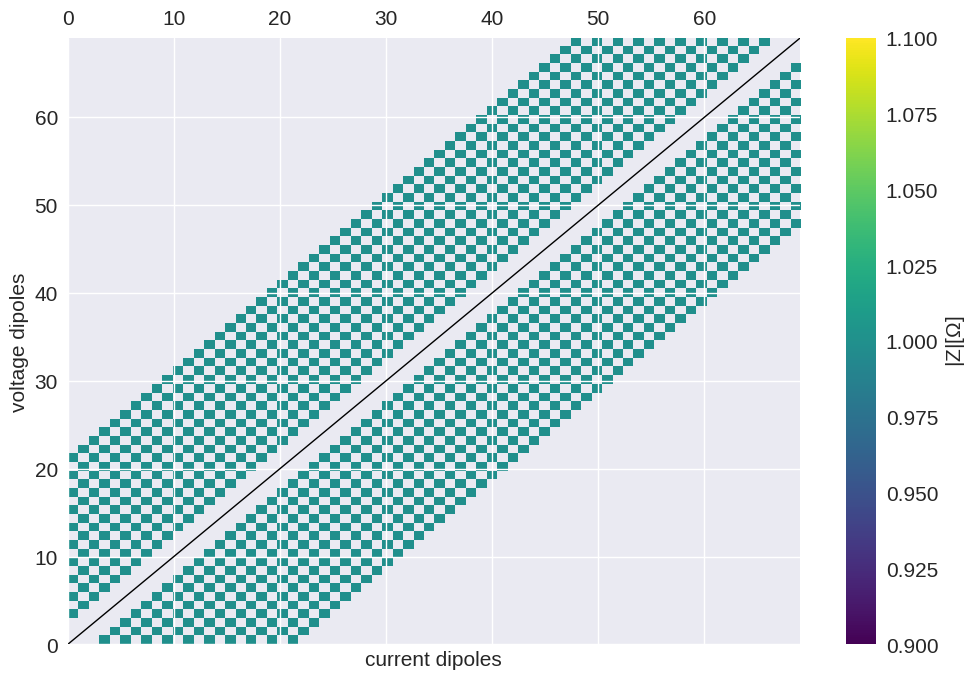

In [71]:


ert = reda.ERT(data=df)
ert.add_dataframe(dfr)
ert.pseudosection_type1()

In [64]:
configs.to_iris_syscal('configs_syscal.txt')

In [65]:
38 - 22

16

In [73]:
ert.data.groupby('id').count()

,a,b,m,n,r,norrec,rdiff
id,,,,,,,
50,2,2,2,2,2,2,2
61,2,2,2,2,2,2,2
72,2,2,2,2,2,2,2
73,2,2,2,2,2,2,2
84,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...
1155,2,2,2,2,2,2,2
1156,2,2,2,2,2,2,2
1157,2,2,2,2,2,2,2
